# Binary Images and MorphologyIntroduces thresholding and binary images, followed by morphology, directional line extraction, and connected-component analysis.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Binary Processing
Binary processing is one of the most fundamental concepts in image processing. It refers to converting an image into a binary image, where each pixel can take only two possible values:
- 0 (black) → represents background.
- 255 (white) → represents foreground (the object of interest).

Advantages of Binary Processing?
- Simplicity → Reduces image complexity, making analysis faster.
- Segmentation → Helps separate objects from the background.
- Preprocessing → Essential step before applying operations like contour detection, shape analysis, and object counting.

## Thresholding
Thresholding is a technique in image processing where we convert a grayscale image into a binary image. This is done by setting a threshold value(T) :

- If a pixel intensity is greater than T, it is set to the maximum value (usually 255, white).
- Otherwise, it is set to the minimum value (0, black).

<code>ret, binary_img = cv2.threshold(input_img, thresh, maxval, type)</code>
- <code>input_img</code> → input image (**must be grayscale**).
- <code>thresh</code> → threshold value T.
- <code>maxval</code> → value assigned if condition is met (usually 255).
- <code>type</code> → thresholding type.

Types of Thresholding:
- <code>cv2.THRESH_BINARY</code>
    - Pixel > T → maxval
    - Pixel ≤ T → 0
- <code>cv2.THRESH_BINARY_INV</code>
    - Inverse of binary.
- <code>cv2.THRESH_TRUNC</code>
    - Pixel > T → T
    - Pixel ≤ T → unchanged
- <code>cv2.THRESH_TOZERO</code>
    - Pixel > T → unchanged
    - Pixel ≤ T → 0
- <code>cv2.THRESH_TOZERO_INV</code>
    - Inverse of ToZero.
    


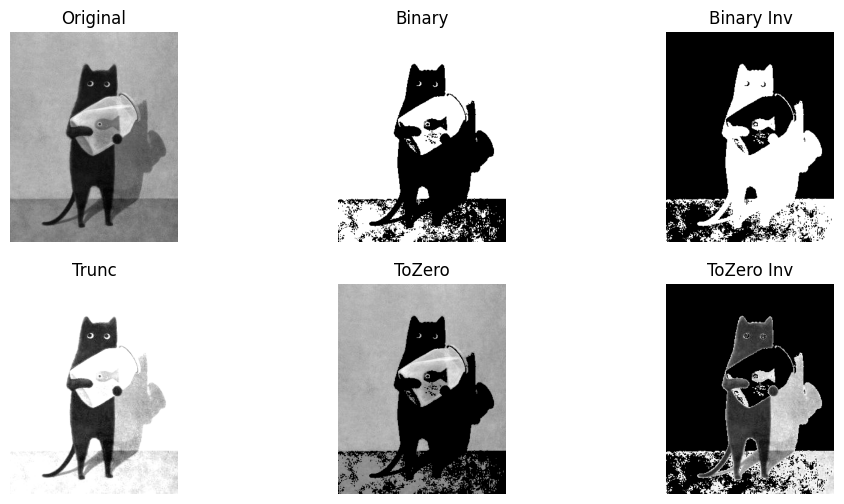

In [2]:
img = cv2.imread("images/Cat.jpg", cv2.IMREAD_GRAYSCALE)

# Apply different thresholding types
_, th_binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, th_binary_inv = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, th_trunc = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
_, th_tozero = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
_, th_tozero_inv = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)

# Plot results
titles = ["Original", "Binary", "Binary Inv", "Trunc", "ToZero", "ToZero Inv"]
images = [img, th_binary, th_binary_inv, th_trunc, th_tozero, th_tozero_inv]

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

## Otsu’s Thresholding
In standard thresholding, we manually pick a threshold value T. But what if the image has complex intensity distributions or we don’t know the best value?
This is where Otsu’s method comes in.

- Otsu’s algorithm automatically calculates the optimal threshold value from the image histogram.

- It works by minimizing the intra-class variance (spread within background and foreground) or equivalently maximizing the inter-class variance (separation between background and foreground).

Mathematically, it evaluates all possible thresholds and selects the one that best separates the two classes (foreground & background).
Otsu’s Thresholding is useful when lighting is uneven, and manual threshold selection is difficult.

**Otsu’s Method works well when the image histogram is bimodal (two peaks: foreground and background).**

<code>ret, otsu_img = cv2.threshold(input_img, thresh, maxval, cv2.THRESH_BINARY + cv2.THRESH_OTSU)</code>

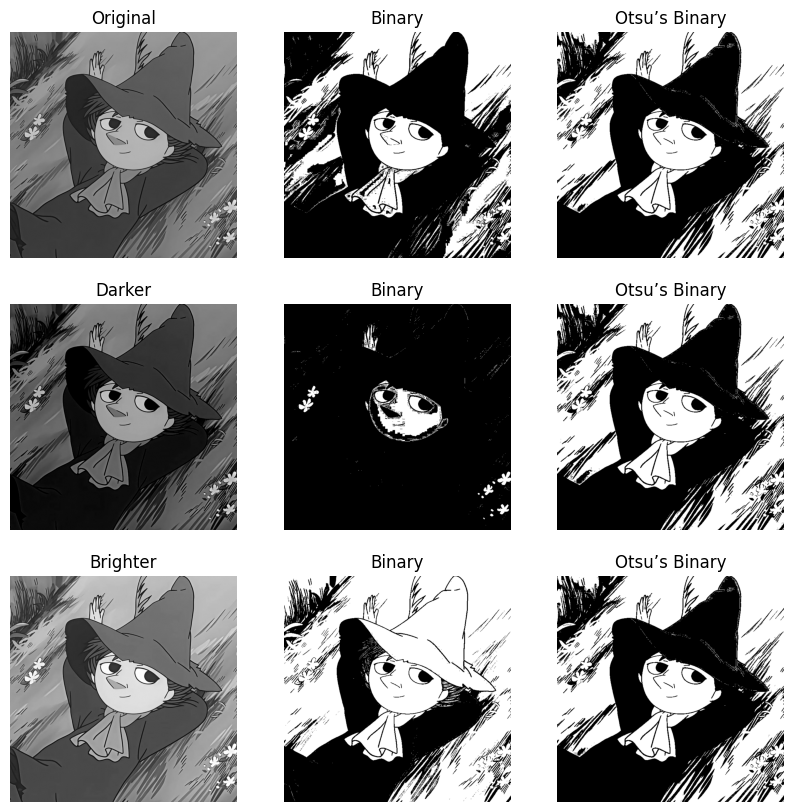

In [23]:
img = cv2.imread("images/Snufkin.jpg",cv2.IMREAD_GRAYSCALE)
darker_img = cv2.add(img.copy(),-50)
brighter_img = cv2.add(img.copy(),50)

_,img_th = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
_,img_otsu = cv2.threshold(img,127,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

_,dimg_th = cv2.threshold(darker_img,127,255,cv2.THRESH_BINARY)
_,dimg_otsu = cv2.threshold(darker_img,127,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

_,bimg_th = cv2.threshold(brighter_img,127,255,cv2.THRESH_BINARY)
_,bimg_otsu = cv2.threshold(brighter_img,127,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

titles = ["Original","Binary","Otsu’s Binary","Darker","Binary","Otsu’s Binary","Brighter","Binary","Otsu’s Binary"]
images = [img, img_th, img_otsu, darker_img, dimg_th, dimg_otsu, brighter_img, bimg_th,bimg_otsu]

plt.figure(figsize=[10,10])
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(titles[i])
    plt.axis("off")


## Adaptive Thresholding
Unlike global thresholding (including Otsu), where one single threshold value is used for the entire image, adaptive thresholding calculates a different threshold for each pixel based on the intensities of its local neighborhood.

This is especially useful when the image has:
- Non-uniform lighting
- Shadows or gradients
- Different brightness regions

Otsu’s Method works well when the image histogram is bimodal. But **when illumination changes across the image**, a single global threshold is not sufficient.
Adaptive Thresholding overcomes this by **computing thresholds locally**.

<code>cv2.adaptiveThreshold(img, maxValue, adaptiveMethod, thresholdType, blockSize, C)</code>
- <code>adaptiveMethod</code> → How the threshold value is calculated for each neighborhood:
    - <code>cv2.ADAPTIVE_THRESH_MEAN_C</code>: mean of the local neighborhood − constant C.
    - <code>cv2.ADAPTIVE_THRESH_GAUSSIAN_C</code>: weighted sum (Gaussian) of the local neighborhood − constant C.

- <code>thresholdType</code> → Usually <code>cv2.THRESH_BINARY</code> or <code>cv2.THRESH_BINARY_INV</code>.

- <code>blockSize</code> → Size of the local neighborhood (must be **odd**, e.g., 3, 5, 11…).

- <code>C</code> → A constant subtracted from the computed threshold (fine-tuning).

Text(0.5, 1.0, 'Adaptive Gaussian')

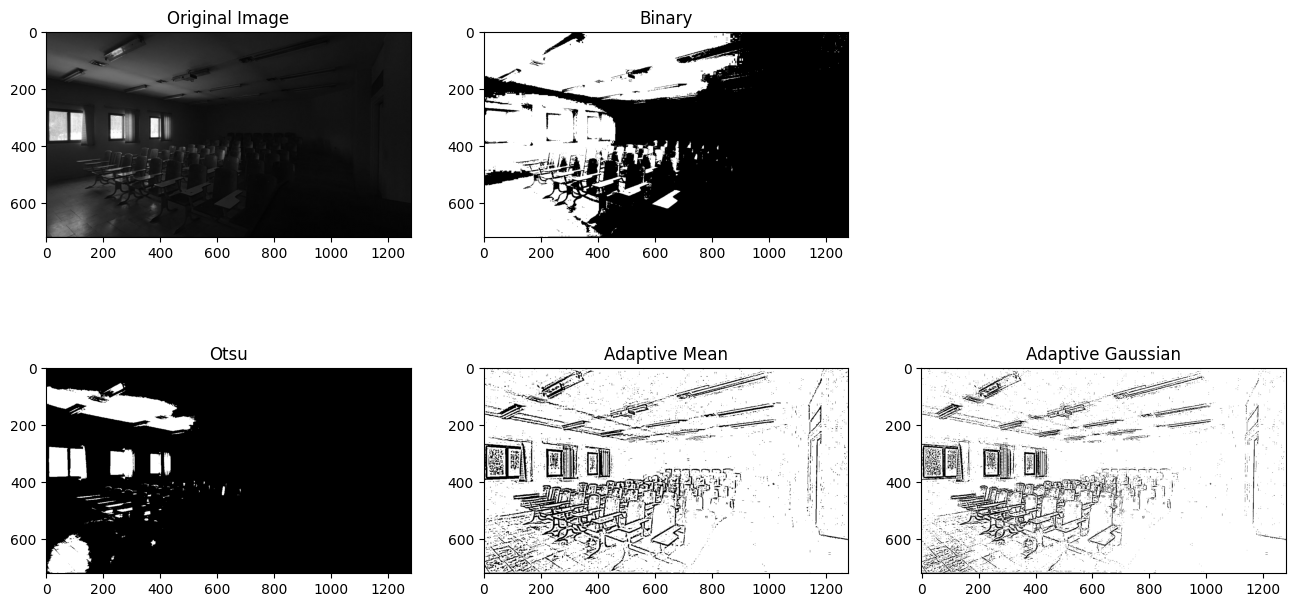

In [9]:
img = cv2.imread("images/classroom.jpg",cv2.IMREAD_GRAYSCALE)

_,th = cv2.threshold(img,25,255,cv2.THRESH_BINARY)
th_mean = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,2)
th_gaussian = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
_,img_otsu = cv2.threshold(img,127,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=[16,8])
plt.subplot(231);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(232);plt.imshow(th,cmap='gray');plt.title("Binary")
plt.subplot(234);plt.imshow(img_otsu,cmap='gray');plt.title("Otsu")
plt.subplot(235);plt.imshow(th_mean,cmap='gray');plt.title("Adaptive Mean")
plt.subplot(236);plt.imshow(th_gaussian,cmap='gray');plt.title("Adaptive Gaussian")

### Comparison:

| Method                   | Description |
|---------------------------|-------------|
| **Binary Thresholding**   | A fixed threshold value is chosen manually.<br>Simple and fast, but not effective if lighting conditions vary. |
| **Otsu’s Method**         | Automatically finds the optimal global threshold from the histogram.<br>Best for images with clear bimodal histograms.<br>Fails under varying illumination. |
| **Adaptive Thresholding** | Computes thresholds locally for each pixel based on its neighborhood.<br>Best for uneven lighting or gradients.<br>More robust in real-world scenarios (documents, scanned papers, outdoor images). |


## Morphological Transformations
Morphological transformations are operations that process images based on their shapes. They rely on a structuring element (<code>kernel</code>) to probe and transform the input image. It is normally performed on binary images. Two basic morphological operators are Erosion and Dilation. Then its variant forms like Opening, Closing, Gradient etc

A kernel (usually a small matrix like 3×3 or 5×5) defines the neighborhood for processing.

Example :$$\begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1\end{bmatrix}$$
This kernel slides across the image, modifying pixels depending on the chosen operation.


### Erosion
Erosion is a morphological transformation that shrinks or thins white (foreground) regions in an image. It works by sliding a structuring element (kernel) across the image.

- A pixel in the output is set to white (1) only if all pixels under the kernel are white (<code>AND Operation</code>).
- The result: white objects become **smaller**, thin lines may disappear, and small noise can be removed.

Mathematical definition: $$A⊖B = \{z∣(B)_z​⊆A\} $$
Example: $$\begin{bmatrix}0&0&1&0&0 \\0&1&1&1&0 \\1&1&1&1&1 \\0&1&1&1&0 \\0&0&1&0&0 \end{bmatrix}⊖\begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1\end{bmatrix}=\begin{bmatrix}0&0&0&0&0 \\0&0&0&0&0 \\0&0&1&0&0 \\0&0&0&0&0 \\0&0&0&0&0 \end{bmatrix}$$
<code>A⊖B = cv2.erode(img= A,kernel= B,iterations= 1)</code>

In [18]:
img = np.array([[ 0, 0, 1, 0, 0],
                [ 0, 1, 1, 1, 0],
                [ 1, 1, 1, 1, 1],
                [ 0, 1, 1, 1, 0],
                [ 0, 0, 1, 0, 0],], np.uint8)

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]], np.uint8)

dilated_image = cv2.erode(img,kernel,iterations = 1)
print(dilated_image)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## Dilation
Dilation is a morphological transformation that grows or thickens white (foreground) regions in an image.

It works by sliding a structuring element (kernel) across the image.

- If any pixel under the kernel is white (1), the pixel at the center is set to white (<code>OR Operation</code>).
- The result: white objects become **larger**, small holes are filled, and gaps between nearby objects may close.

Mathematical definition: $$A⊕B=\{z∣(B)_z​∩A\neq\emptyset\}$$
Example: $$\begin{bmatrix}0&0&1&0&0 \\0&1&0&1&0 \\1&0&0&0&1 \\0&1&0&1&0 \\0&0&0&0&0 \end{bmatrix}⊕\begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1\end{bmatrix}=\begin{bmatrix}1&1&1&1&1 \\1&1&1&1&1 \\1&1&1&1&1 \\1&1&1&1&1 \\1&1&1&1&1 \end{bmatrix}$$
<code>A⊕B = cv2.dilate(img= A,kernel= B,iterations= 1)</code>

In [6]:
img = np.array([[ 0, 0, 1, 0, 0],
                [ 0, 1, 0, 1, 0],
                [ 1, 0, 0, 0, 1],
                [ 0, 1, 0, 1, 0],
                [ 0, 0, 0, 0, 0],], np.uint8)

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]], np.uint8)

dilated_image = cv2.dilate(img,kernel,iterations = 1)
print(dilated_image)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


## Opening
Erosion followed by Dilation.

- Removes small white noise (Salt Noises).
- Preserves larger object structures.

Example: $$\begin{bmatrix}1&1&1&0&0 \\1&1&1&0&0 \\1&1&1&0&0 \\0&0&0&0&1 \\1&0&0&1&0 \end{bmatrix}.\begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1\end{bmatrix}=\begin{bmatrix}1&1&1&0&0 \\1&1&1&0&0 \\1&1&1&0&0 \\0&0&0&0&0 \\0&0&0&0&0 \end{bmatrix}$$
<code>opening = cv.morphologyEx(img, cv2.MORPH_OPEN, kernel)</code>


In [16]:
img = np.array([[ 1, 1, 1, 0, 0],
                [ 1, 1, 1, 0, 0],
                [ 1, 1, 1, 0, 0],
                [ 0, 0, 0, 0, 1],
                [ 1, 0, 0, 1, 0],], np.uint8)

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]], np.uint8)

opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)
opening


array([[1, 1, 1, 0, 0],
       [1, 1, 1, 0, 0],
       [1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint8)

## Closing
Dilation followed by Erosion.
- Fills small black holes inside objects (Pepper Noises).
- Connects nearby white objects.

Example: $$\begin{bmatrix}0&0&0&0&0&0&0 \\0&0&0&0&0&0&0 \\0&0&1&1&1&0&0 \\0&0&1&0&1&0&0 \\0&0&1&1&1&0&0 \\0&0&0&0&0&0&0 \\0&0&0&0&0&0&0 \end{bmatrix}.\begin{bmatrix}1 & 1 & 1 \\1 & 1 & 1 \\1 & 1 & 1\end{bmatrix}=\begin{bmatrix}0&0&0&0&0&0&0 \\0&0&0&0&0&0&0 \\0&0&1&1&1&0&0 \\0&0&1&1&1&0&0 \\0&0&1&1&1&0&0 \\0&0&0&0&0&0&0 \\0&0&0&0&0&0&0 \end{bmatrix}$$
<code>closing = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)</code>

In [40]:

img = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0]
], np.uint8)

kernel = np.ones((3,3),np.uint8)

closing = cv2.morphologyEx(img,cv2.MORPH_CLOSE,kernel)
closing


array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]], dtype=uint8)

### Image Example

Text(0.5, 1.0, 'Closing')

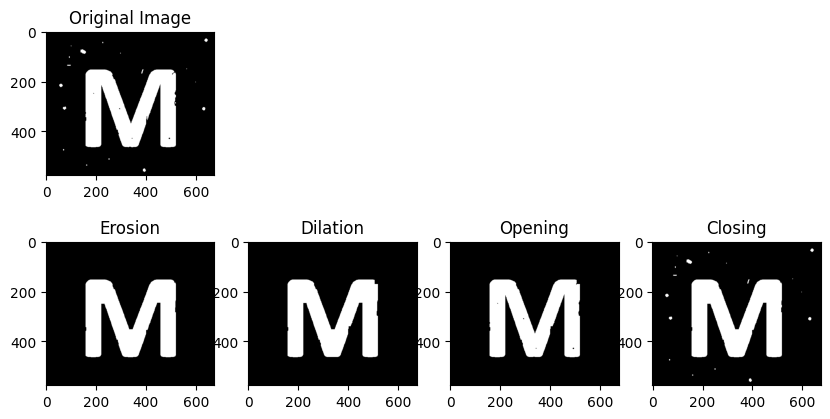

In [ ]:
img = cv2.imread("images/M-noise.png",cv2.IMREAD_GRAYSCALE)
_,img = cv2.threshold(img,40,255,cv2.THRESH_BINARY) # Convert to binary

kernel = np.ones((13,13),np.uint8)

erosion = cv2.erode(img,kernel,iterations=1)
dilation = cv2.dilate(img,kernel,iterations=1)
opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)
closing = cv2.morphologyEx(img,cv2.MORPH_CLOSE,kernel)

plt.figure(figsize=[10,5])
plt.subplot(241);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(245);plt.imshow(erosion,cmap='gray');plt.title("Erosion")
plt.subplot(246);plt.imshow(dilation,cmap='gray');plt.title("Dilation")
plt.subplot(247);plt.imshow(opening,cmap='gray');plt.title("Opening")
plt.subplot(248);plt.imshow(closing,cmap='gray');plt.title("Closing")


## Kernels
In mathematical morphology, the structuring element defines the shape and size of the neighborhood used to process the image.
In OpenCV, you can use:

<code>cv2.getStructuringElement(shape, ksize):</code>
- <code>shape</code> → Type of structuring element:
    - <code>cv2.MORPH_RECT</code> → rectangular kernel
    - <code>cv2.MORPH_ELLIPSE</code> → elliptical (disk-shaped) kernel
    - <code>cv2.MORPH_CROSS</code> → cross-shaped kernel

- <code>ksize</code> → Size of the kernel (width, height), e.g., (5, 5).

different shapes of kernels behave differently in morphology.

- Rect → affects square neighborhoods.
- Ellipse → smooths shapes more naturally.
- Cross → emphasizes vertical/horizontal connections.

Text(0.5, 1.0, 'Opening CROSS')

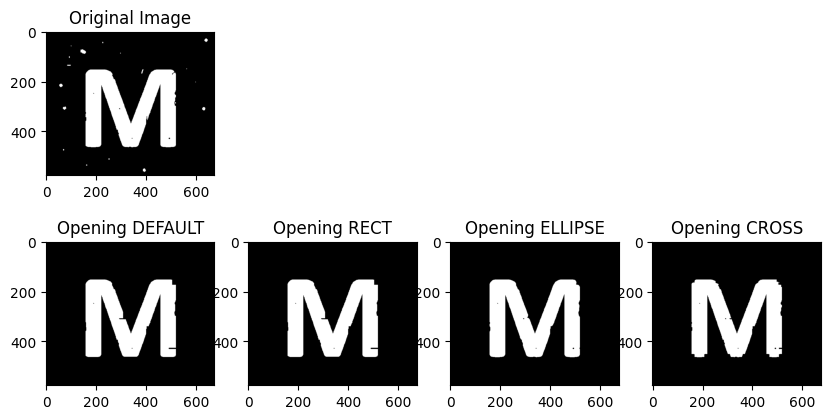

In [90]:
img = cv2.imread("images/M-noise.png",cv2.IMREAD_GRAYSCALE)
_,img = cv2.threshold(img,40,255,cv2.THRESH_BINARY) # Convert to binary

kernel = np.ones((25,25),np.uint8)
kernel1 = cv2.getStructuringElement(cv2.MORPH_RECT,(25,25))
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(25,25))
kernel3 = cv2.getStructuringElement(cv2.MORPH_CROSS,(25,25))


opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)
opening1 = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel1)
opening2 = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel2)
opening3 = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel3)


plt.figure(figsize=[10,5])
plt.subplot(241);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(245);plt.imshow(opening,cmap='gray');plt.title("Opening DEFAULT")
plt.subplot(246);plt.imshow(opening1,cmap='gray');plt.title("Opening RECT")
plt.subplot(247);plt.imshow(opening2,cmap='gray');plt.title("Opening ELLIPSE")
plt.subplot(248);plt.imshow(opening3,cmap='gray');plt.title("Opening CROSS")


## Removing Horizontal and Vertical Lines
In many scanned documents or structured images, unwanted horizontal or vertical lines (like table borders, underlines, or gridlines) may appear. Morphological operations with directional kernels can be used to detect and remove them:

- To detect vertical lines, use a tall, narrow kernel (e.g., <code>cv2.getStructuringElement(cv2.MORPH_RECT, (1, N))</code>) to create a $N\times 1$ matrix.

- To detect horizontal lines, use a wide, flat kernel (e.g., <code>cv2.getStructuringElement(cv2.MORPH_RECT, (N, 1))</code>) to create a $1\times N$ matrix.

with <code>cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)</code>, the lines can be subtracted from the original image, leaving the content intact.

Text(0.5, 1.0, 'Horizental lines')

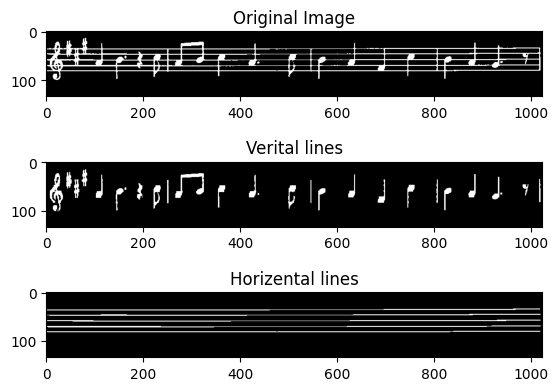

In [143]:
img = cv2.imread("images/notes.png",cv2.IMREAD_GRAYSCALE)
_,img = cv2.threshold(img,128,255,cv2.THRESH_BINARY_INV) # Convert to binary
height,width = img.shape
vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(1,height//30))
vert_img = cv2.morphologyEx(img,cv2.MORPH_OPEN,vert_kernel)

hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(width//20,1))
hor_img = cv2.morphologyEx(img,cv2.MORPH_OPEN,hor_kernel)

plt.subplot(311);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(312);plt.imshow(vert_img,cmap='gray');plt.title("Verital lines")
plt.subplot(313);plt.imshow(hor_img,cmap='gray');plt.title("Horizental lines")

## Connected Components
In binary images, connected components analysis is used to label and extract distinct objects (or blobs). This is widely used in object counting, segmentation, OCR preprocessing, and blob analysis. A connected component is a group of white pixels (value = 255) that are connected to each other by 4-connectivity (up, down, left, right) or 8-connectivity (diagonal connections included).

<code>num_labels, labels = cv2.connectedComponents(binary img, connectivity=8)</code><code></code>
- <code>num_labels</code> → Number of labels found (including background).

- <code>labels</code> → A 2D array (same size as input) where each pixel is replaced by its component label:
    - 0 → background
    - 1,2,... → object IDs

<code>num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary img, connectivity=8)</code> 

is the extended version that gives extra information for each connected component.
- <code>stats</code> → A matrix where each row describes a component:
    - <code>stats[i, cv2.CC_STAT_LEFT]</code> → x coordinate of the bounding box
    - <code>stats[i, cv2.CC_STAT_TOP]</code> → y coordinate of the bounding box
    - <code>stats[i, cv2.CC_STAT_WIDTH]</code> → width of the bounding box
    - <code>stats[i, cv2.CC_STAT_HEIGHT]</code> → height of the bounding box
    - <code>stats[i, cv2.CC_STAT_AREA]</code> → area (number of pixels in the component)

- <code>centroids</code> → (x,y) coordinates of the centroid of each component.


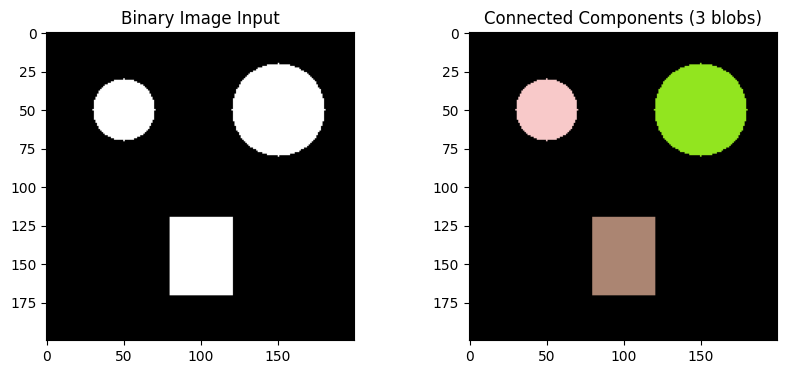

Number of connected components (excluding background): 3
Stats [x,y,width,height,area]:
 [[ 120   20   61   61 2821]
 [  30   30   41   41 1257]
 [  80  120   41   51 2091]]
Centroids:
 [[150.  50.]
 [ 50.  50.]
 [100. 145.]]


In [20]:
img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (50, 50), 20, 255, -1)     # Blob 1
cv2.circle(img, (150, 50), 30, 255, -1)    # Blob 2
cv2.rectangle(img, (80, 120), (120, 170), 255, -1)  # Blob 3

# Connected components 
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)

# Visualize result with random colors
components = np.zeros((200, 200, 3), dtype=np.uint8)
for i in range(1, num_labels):  # skip background (label = 0)
    mask = labels == i # creates a boolean mask 
    components[mask] = np.random.randint(0, 255, 3) # generates a random RGB color

# Plot
plt.figure(figsize=(10,4))
plt.subplot(121); plt.imshow(img, cmap="gray"); plt.title("Binary Image Input")
plt.subplot(122); plt.imshow(components); plt.title(f"Connected Components ({num_labels-1} blobs)")
plt.show()

# Print statistics
print("Number of connected components (excluding background):", num_labels-1)
print("Stats [x,y,width,height,area]:\n", stats[1:])  # skip background
print("Centroids:\n", centroids[1:])